In [91]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [92]:
df= pd.read_csv("/content/netflix_customer_churn.csv")
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [93]:
df.tail()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi
4999,82aeef39-ddb0-40ad-bae1-5c436e0cf042,57,Male,Basic,1.62,17,Africa,Mobile,8.99,1,Crypto,2,0.09,Action


In [94]:
df.isna().sum()

,0
customer_id,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0


In [95]:
df.duplicated().sum()


np.int64(0)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [97]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [98]:
df["churned"].value_counts(normalize=True).mul(100).round(2)

,proportion
churned,
1,50.3
0,49.7


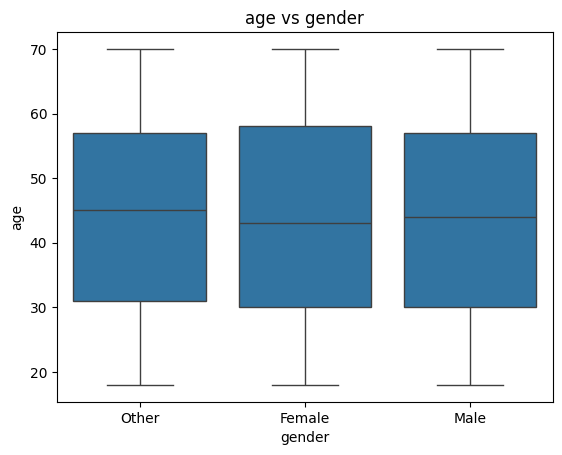

In [99]:
sns.boxplot(y=df['age'],x=df['gender'])
plt.title("age vs gender")
plt.show()

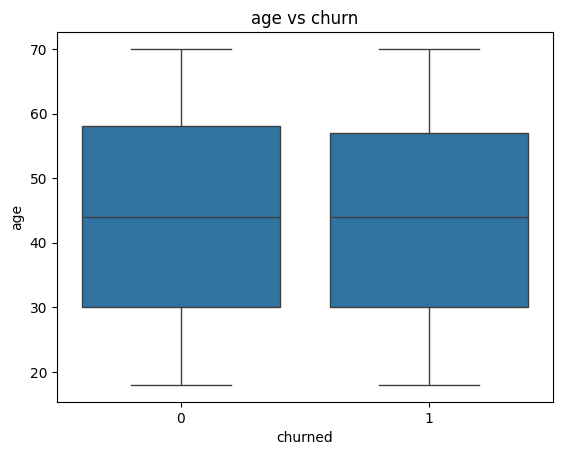

In [100]:
sns.boxplot(x=df['churned'],y=df['age'])
plt.title("age vs churn")
plt.show()

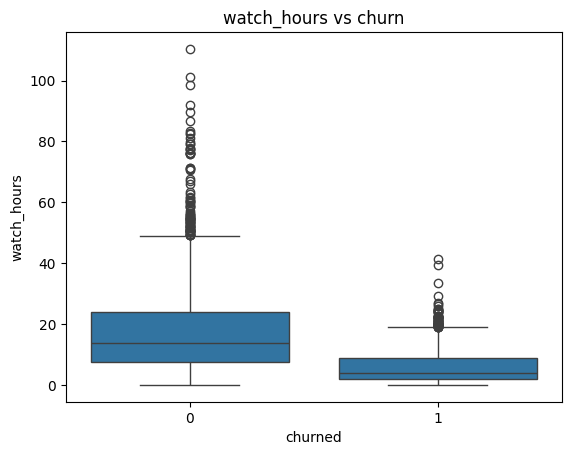

In [101]:
sns.boxplot(x=df['churned'],y=df['watch_hours'])
plt.title("watch_hours vs churn")
plt.show()

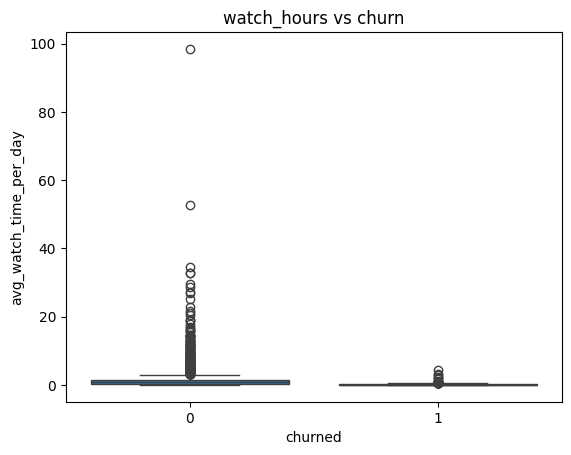

In [102]:
sns.boxplot(x=df['churned'],y=df['avg_watch_time_per_day'])
plt.title("watch_hours vs churn")
plt.show()

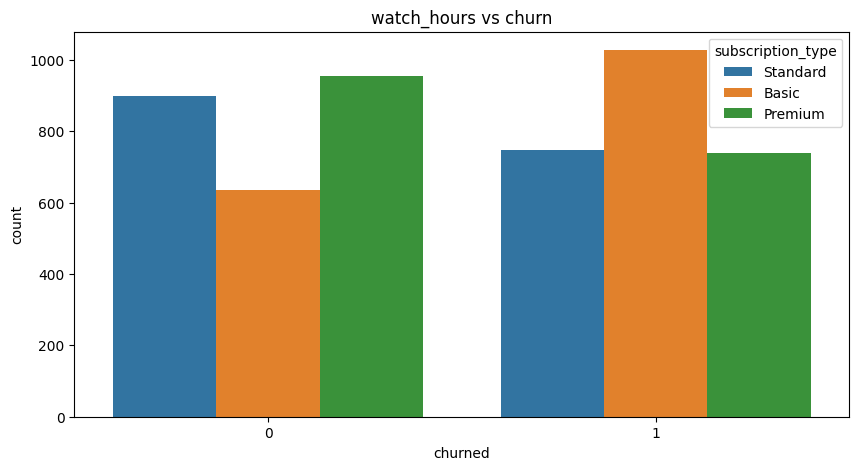

In [103]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['churned'],hue=df['subscription_type'])
plt.title("watch_hours vs churn")
plt.show()

In [104]:
pd.crosstab(df["region"],df["churned"],normalize="index").round(3)

churned,0,1
region,,
Africa,0.517,0.483
Asia,0.493,0.507
Europe,0.483,0.517
North America,0.505,0.495
Oceania,0.499,0.501
South America,0.486,0.514


In [105]:
pd.crosstab(df["payment_method"],df["churned"],normalize="index").round(3)

churned,0,1
payment_method,,
Credit Card,0.564,0.436
Crypto,0.403,0.597
Debit Card,0.563,0.437
Gift Card,0.422,0.578
PayPal,0.529,0.471


In [106]:
numeric_cols = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
watch_hours: 238 outliers
last_login_days: 0 outliers
monthly_fee: 0 outliers
number_of_profiles: 0 outliers
avg_watch_time_per_day: 549 outliers


In [107]:
for col in ["watch_hours", "avg_watch_time_per_day"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print("Lower limit:", lower)
    print("Upper limit:", upper)
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Outlier count:", len(outliers))


watch_hours
Lower limit: -15.70125
Upper limit: 35.06875
Minimum: 0.01
Maximum: 110.4
Outlier count: 238

avg_watch_time_per_day
Lower limit: -0.805
Upper limit: 1.635
Minimum: 0.0
Maximum: 98.42
Outlier count: 549


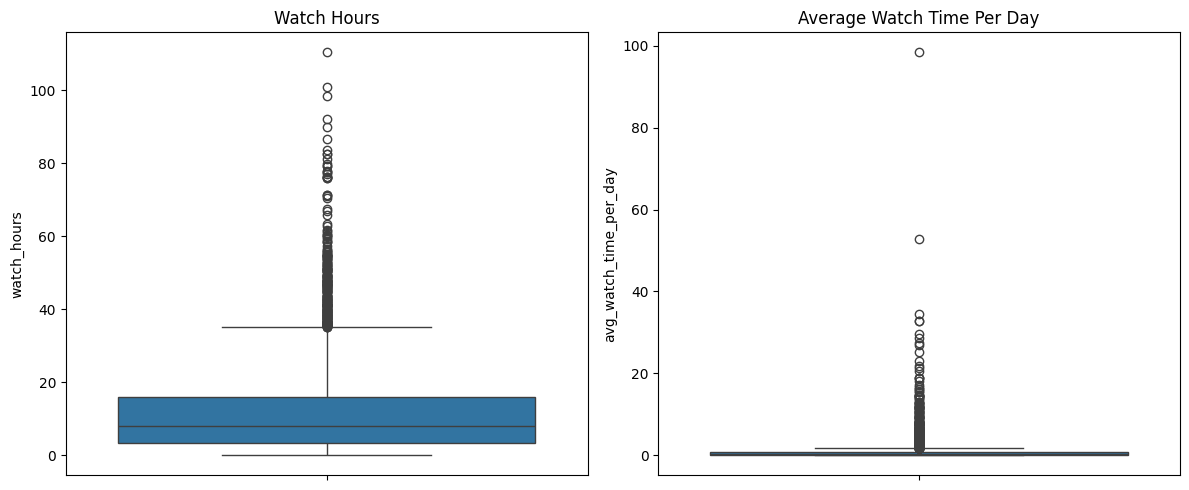

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["watch_hours"], ax=axes[0])
axes[0].set_title("Watch Hours")

sns.boxplot(y=df["avg_watch_time_per_day"], ax=axes[1])
axes[1].set_title("Average Watch Time Per Day")

plt.tight_layout()
plt.show()

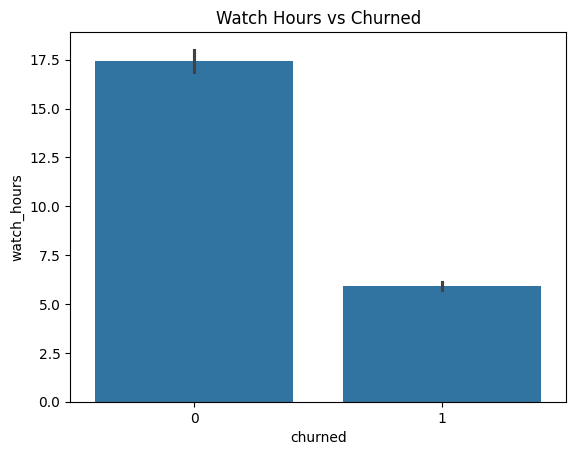

In [109]:
sns.barplot(x=df["churned"], y=df["watch_hours"])
plt.title("Watch Hours vs Churned")
plt.show()

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

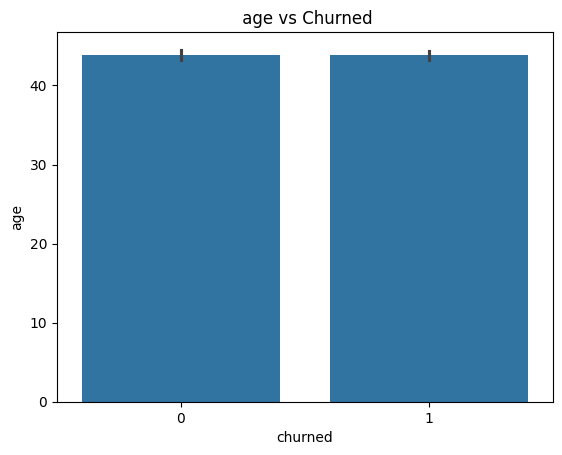

In [111]:
sns.barplot(x=df["churned"], y=df["age"])
plt.title(" age vs Churned")
plt.show()

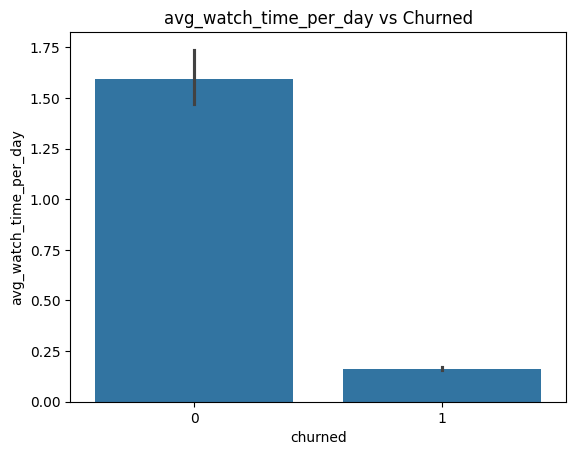

In [112]:
sns.barplot(x=df["churned"], y=df["avg_watch_time_per_day"])
plt.title("avg_watch_time_per_day vs Churned")
plt.show()

In [113]:
X = df.drop(columns=["churned"])
y = df["churned"]

In [114]:
from sklearn.model_selection import train_test_split
# train_test_split()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [115]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4000, 13)
X_test : (1000, 13)
y_train: (4000,)
y_test : (1000,)


In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]

categorical_cols = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [117]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(type(X_train_processed))
print(X_train_processed.shape)
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

<class 'numpy.ndarray'>
(4000, 35)
['num__age' 'num__watch_hours' 'num__last_login_days' 'num__monthly_fee'
 'num__number_of_profiles' 'num__avg_watch_time_per_day'
 'cat__gender_Female' 'cat__gender_Male' 'cat__gender_Other'
 'cat__subscription_type_Basic' 'cat__subscription_type_Premium'
 'cat__subscription_type_Standard' 'cat__region_Africa' 'cat__region_Asia'
 'cat__region_Europe' 'cat__region_North America' 'cat__region_Oceania'
 'cat__region_South America' 'cat__device_Desktop' 'cat__device_Laptop'
 'cat__device_Mobile' 'cat__device_TV' 'cat__device_Tablet'
 'cat__payment_method_Credit Card' 'cat__payment_method_Crypto'
 'cat__payment_method_Debit Card' 'cat__payment_method_Gift Card'
 'cat__payment_method_PayPal' 'cat__favorite_genre_Action'
 'cat__favorite_genre_Comedy' 'cat__favorite_genre_Documentary'
 'cat__favorite_genre_Drama' 'cat__favorite_genre_Horror'
 'cat__favorite_genre_Romance' 'cat__favorite_genre_Sci-Fi']


In [118]:
from sklearn.linear_model import LogisticRegression
lg_model = LogisticRegression(max_iter=100,random_state=42)
lg_model.fit(X_train_processed, y_train)
y_pred = lg_model.predict(X_test_processed)

In [119]:
print(y_pred)

[1 1 0 1 1 1 1 1 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 1 1 0 1 1 1 1 0 0 0 0
 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 1
 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0
 1 0 1 1 1 1 0 0 1 1 0 0 0 1 1 1 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 1
 1 1 1 0 1 0 1 0 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1
 0 0 0 0 1 1 1 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 1 0
 0 1 0 0 1 0 1 1 0 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 0 0 1 1
 1 1 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 1 1 1
 1 0 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0
 0 1 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 0 1 1 1 0 0 1 1 1
 1 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0
 0 0 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0 1 0 0 1 1
 1 1 1 1 1 1 1 1 0 1 0 1 

In [120]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, confusion_matrix, classification_report)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.897
Precision: 0.8829174664107485
Recall: 0.9163346613545816
F1 Score: 0.8993157380254154


In [121]:
y_prob = lg_model.predict_proba(X_test_processed)[:, 1]

print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

ROC-AUC  : 0.9663434614953839


In [122]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89       498
           1       0.88      0.92      0.90       502

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



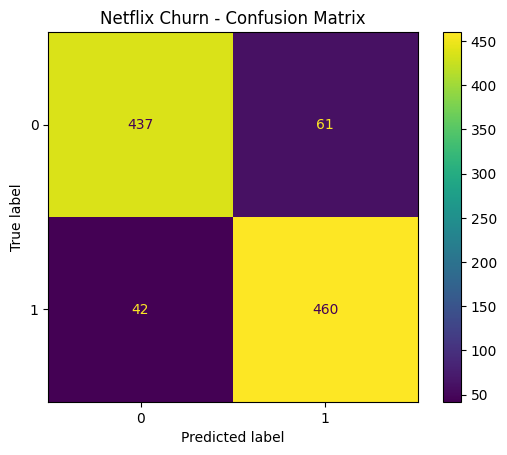

In [123]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Netflix Churn - Confusion Matrix")
plt.show()

In [124]:
from sklearn.ensemble import RandomForestClassifier
rf_model =RandomForestClassifier(random_state=42)
rf_model.fit(X_train_processed, y_train)
y_pred = rf_model.predict(X_test_processed)
print(y_pred)

[0 1 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 1 1 0 1 1 1 0 0 0 1 0
 0 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 1 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1
 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0
 1 0 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 0 1
 1 1 1 1 1 0 1 0 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1
 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 0 0
 1 1 1 0 1 0 1 1 0 0 1 0 1 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1
 1 0 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1
 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1
 1 0 1 1 0 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0
 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 0 0 1 1
 1 1 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 0
 0 0 1 0 1 1 0 1 0 1 0 1 0 1 1 1 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 

In [125]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
y_prob = rf_model.predict_proba(X_test_processed)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.978
Precision: 0.9838709677419355
Recall: 0.9721115537848606
F1 Score: 0.9779559118236473
ROC-AUC: 0.9976459623353974
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       498
           1       0.98      0.97      0.98       502

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [126]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed, y_train)
y_pred = dt_model.predict(X_test_processed)
print(y_pred)

[0 1 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 1 1 0 1 1 1 0 0 0 1 0
 0 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 1 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1
 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0
 1 0 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 0 1
 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 1 1 1 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1
 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 0 0
 1 1 1 0 1 0 1 1 0 1 1 0 1 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1
 1 0 1 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 1 0 0 1 1
 1 1 0 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1
 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0
 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 0 0 1 1
 1 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 0
 1 0 1 0 1 1 0 1 0 1 0 1 0 1 1 1 0 1 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 

In [127]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
y_prob = dt_model.predict_proba(X_test_processed)[:, 1]
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.98
Precision: 0.9762845849802372
Recall: 0.9840637450199203
F1 Score: 0.9801587301587301
ROC-AUC  : 0.9799836797388759
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       498
           1       0.98      0.98      0.98       502

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [128]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_processed, y_train)
y_pred = xgb_model.predict(X_test_processed)
print(y_pred)

[0 1 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 1 1 0 1 1 1 0 0 0 1 0
 0 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 1 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1
 0 0 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0
 1 0 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 1 0 1
 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1
 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 0 0
 0 1 1 0 1 0 1 1 0 0 0 0 1 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1
 1 0 1 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 1 0 0 1 1
 1 1 0 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1
 1 0 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0
 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 0 0 1 1
 1 1 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 0
 1 0 1 0 1 1 0 1 0 1 0 1 0 1 1 1 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 1 1
 1 1 1 1 1 1 1 1 0 1 0 1 

In [129]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
y_prob = xgb_model.predict_proba(X_test_processed)[:, 1]
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.996
Precision: 1.0
Recall: 0.9920318725099602
F1 Score: 0.996
ROC-AUC  : 0.9998719979519672
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       498
           1       1.00      0.99      1.00       502

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [130]:
print(df.corr(numeric_only=True)["churned"].sort_values(ascending=False))

churned                   1.000000
last_login_days           0.471590
age                      -0.003515
monthly_fee              -0.152117
number_of_profiles       -0.158614
avg_watch_time_per_day   -0.272958
watch_hours              -0.479916
Name: churned, dtype: float64


In [131]:
print(df.groupby("churned")[
    [
        "watch_hours",
        "last_login_days",
        "monthly_fee",
        "number_of_profiles",
        "avg_watch_time_per_day"
    ]
].mean())

         watch_hours  last_login_days  monthly_fee  number_of_profiles  \
churned                                                                  
0          17.449590        21.771026    14.248350            3.250302   
1           5.918497        38.309344    13.125189            2.801193   

         avg_watch_time_per_day  
churned                          
0                      1.594133  
1                      0.164048  


In [132]:
for col in categorical_cols:
    print("\n", col)
    print(pd.crosstab(
        df[col],
        df["churned"],
        normalize="index"
    ))


 gender
churned         0         1
gender                     
Female   0.489188  0.510812
Male     0.500000  0.500000
Other    0.502141  0.497859

 subscription_type
churned                   0         1
subscription_type                    
Basic              0.381698  0.618302
Premium            0.562906  0.437094
Standard           0.545565  0.454435

 region
churned               0         1
region                           
Africa         0.516812  0.483188
Asia           0.493460  0.506540
Europe         0.483276  0.516724
North America  0.505288  0.494712
Oceania        0.499346  0.500654
South America  0.485682  0.514318

 device
churned         0         1
device                     
Desktop  0.507903  0.492097
Laptop   0.482107  0.517893
Mobile   0.495020  0.504980
TV       0.500504  0.499496
Tablet   0.500000  0.500000

 payment_method
churned                0         1
payment_method                    
Credit Card     0.564234  0.435766
Crypto          0.403015  0.59698

In [133]:
best_model = xgb_model
best_model_name = "XGBoost"

In [136]:
import joblib
joblib.dump(best_model, "best_churn_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
print("Best Model:", best_model_name)

Best Model: XGBoost


In [138]:
# import joblib
# best_churn_model = joblib.load('best_churn_model.pkl')

# comparison = pd.DataFrame({
#     "Actual": y_test.values[:10],
#     "Predicted": best_churn_model.predict(X_test_processed[:10])
# })

# comparison

In [139]:
import pandas as pd

y_pred = xgb_model.predict(X_test_processed)

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison_df.head(10))

   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       1          1
4       1          1
5       1          1
6       1          0
7       1          1
8       0          0
9       0          0


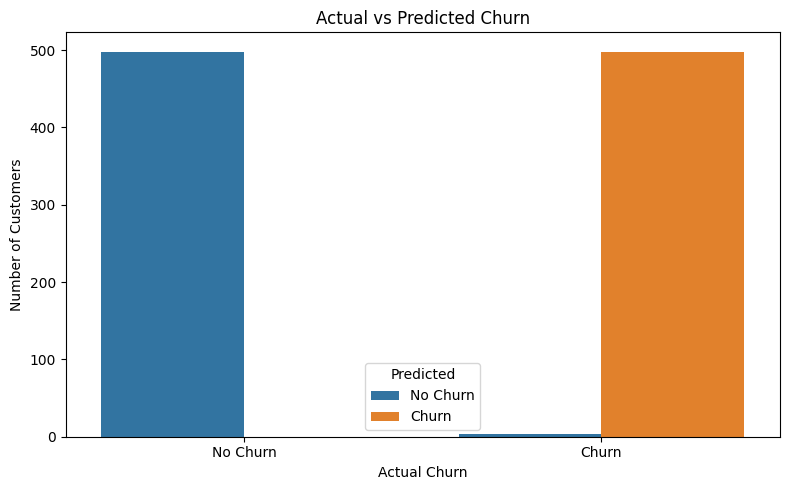

In [141]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=comparison_df,
    x="Actual",
    hue="Predicted"
)

plt.title("Actual vs Predicted Churn")
plt.xlabel("Actual Churn")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Churn", "Churn"])

plt.legend(
    title="Predicted",
    labels=["No Churn", "Churn"]
)

plt.tight_layout()
plt.show()

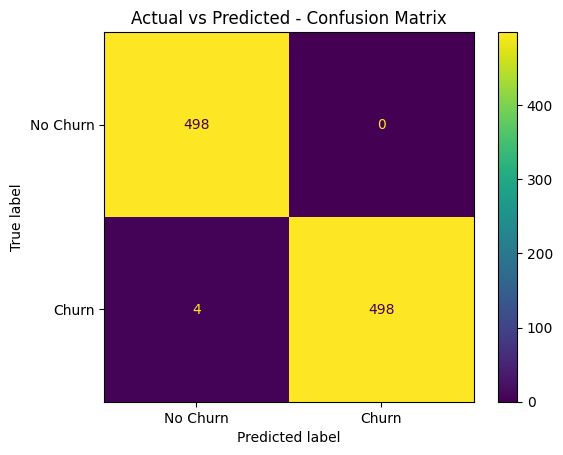

In [142]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("Actual vs Predicted - Confusion Matrix")
plt.show()

In [144]:
feature_names = preprocessor.get_feature_names_out()

print("Total Features:", len(feature_names))
print(feature_names)
joblib.dump(
    feature_names.tolist(),
    "features.pkl"
)

print("features.pkl saved successfully!")

Total Features: 35
['num__age' 'num__watch_hours' 'num__last_login_days' 'num__monthly_fee'
 'num__number_of_profiles' 'num__avg_watch_time_per_day'
 'cat__gender_Female' 'cat__gender_Male' 'cat__gender_Other'
 'cat__subscription_type_Basic' 'cat__subscription_type_Premium'
 'cat__subscription_type_Standard' 'cat__region_Africa' 'cat__region_Asia'
 'cat__region_Europe' 'cat__region_North America' 'cat__region_Oceania'
 'cat__region_South America' 'cat__device_Desktop' 'cat__device_Laptop'
 'cat__device_Mobile' 'cat__device_TV' 'cat__device_Tablet'
 'cat__payment_method_Credit Card' 'cat__payment_method_Crypto'
 'cat__payment_method_Debit Card' 'cat__payment_method_Gift Card'
 'cat__payment_method_PayPal' 'cat__favorite_genre_Action'
 'cat__favorite_genre_Comedy' 'cat__favorite_genre_Documentary'
 'cat__favorite_genre_Drama' 'cat__favorite_genre_Horror'
 'cat__favorite_genre_Romance' 'cat__favorite_genre_Sci-Fi']
features.pkl saved successfully!
